In [1]:
from dataset import *
from config import *

In [2]:
train, test, embeddings, artists, test_targets = get_general_data()
item_to_token = get_item_to_token(train, vocab_size=None)

train_events = get_train_events(train, item_to_token)
train_histories = get_train_histories(train_events)

In [3]:
vocab_size = item_to_token['token_id'].max() + 1

In [140]:
dataloader = TrainingDataset(train_histories, batch_size=32,
                             seq_len=MAX_TRAIN_EVENTS_PER_USER,
                             shuffle=True, device='mps',
                             uniform_negative_items=30_000,
                             in_batch_negative_items=0,
                             vocab_size=vocab_size,
                             pin_memory=False)

In [141]:
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np
import math
import torch

15.461878981844286
15.95573000189958
15.454230534782415
15.94198374949232
15.45659462372029
15.9502693963294
15.457288285629978
15.949777792365897
15.465801007781986
15.95889564534927


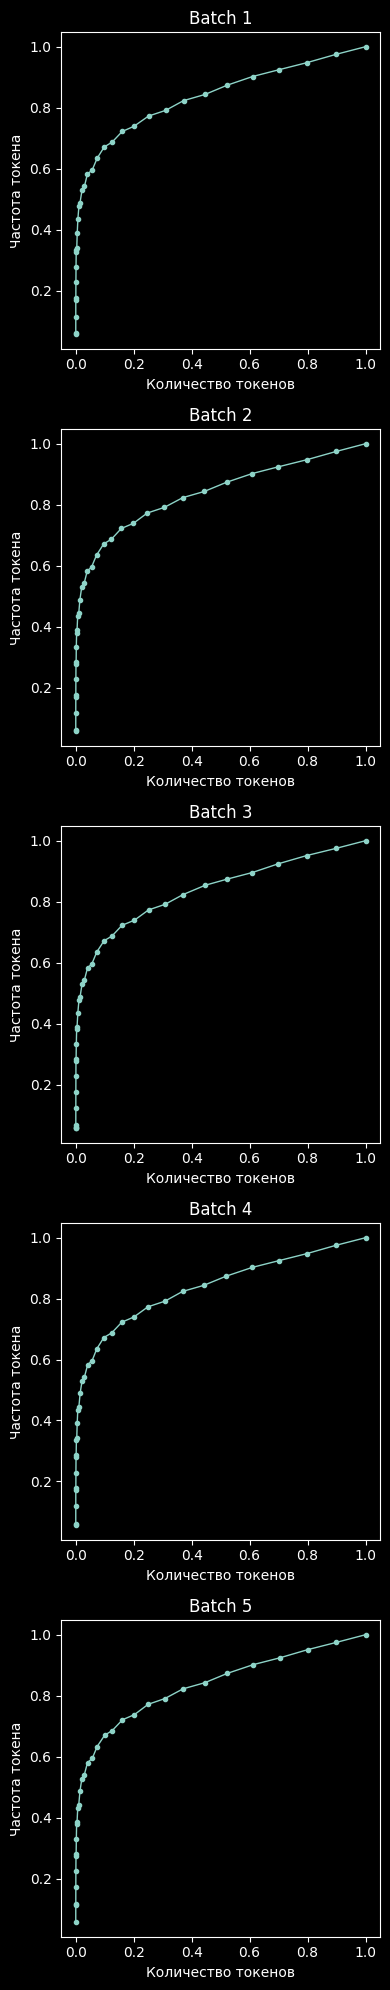

In [148]:
it = iter(dataloader)
fig, axes = plt.subplots(5, 1, figsize=(4, 20))
axes = axes.flatten()

for idx in range(5):
    batch = next(it)

    tokens = batch.negatives.flatten()
    inputs = batch.inputs.flatten()

    for j in range(80):
        batch = next(it)
        inputs = torch.concat([inputs, batch.inputs.flatten()])
        tokens = torch.concat([tokens, batch.negatives.flatten()])

    inputs = inputs.flatten().unique().tolist()
    tokens = tokens.tolist()

    cnt = Counter(tokens)
    frequencies = list(cnt[i] for i in set(inputs) - {0})
    print(sum(frequencies) / len(frequencies))
    print(math.sqrt(sum(i*i for i in frequencies) / len(frequencies)))

    # Считаем, сколько токенов имеют каждую частоту
    freq_counts = Counter(frequencies)
    x_vals = sorted(freq_counts.keys(), key=lambda x: freq_counts[x])  # частоты (1,2,3,...)
    y_vals = [freq_counts[f] for f in x_vals]  # количество токенов с такой частотой
    s = sum(x_vals)  # общее количество токенов
    s1 = sum(y_vals)
    for i in range(1, len(x_vals)):
        x_vals[i] += x_vals[i - 1]  # кумулятивная сумма
    for i in range(1, len(y_vals)):
        y_vals[i] += y_vals[i - 1]  # кумулятивная сумма
    axes[idx].plot(list(i / s1 for i in y_vals), list(i / s for i in x_vals),
                   marker='o', linestyle='-', linewidth=1, markersize=3)
    axes[idx].set_ylabel('Частота токена')
    axes[idx].set_xlabel('Количество токенов')
    axes[idx].set_title(f'Batch {idx + 1}')

    # Если данные разбросаны, включим логарифмические оси, чтобы увидеть прямую
    # axes[idx].set_xscale('log')
    # axes[idx].set_yscale('log')

plt.tight_layout()
plt.show()